# Experimenting with FAISS
----


##### **Notebook Summary**

In this notebook I build a vector database using FAISS with my labelled email dataset, following this tutorial: https://github.com/facebookresearch/faiss/wiki/Getting-started

The goal is to evaluate the search quality on a smaller, labelled subset before deciding whether to scale the database to the full 30,000 emails. 

The reasoning behind this approach is that if performance is weak on the labelled set, adding more data could introduce more noise rather than improve the quality of returned emails.

## Set Up
----

In [1]:
import faiss
import numpy as np
import joblib
import pandas as pd
import spacy

from sentence_transformers import SentenceTransformer

## Functions
----

In [2]:
nlp = spacy.load('en_core_web_sm')

In [3]:
def remove_names(text):
    text = str(text)
    doc = nlp(text)
    for e in reversed(doc.ents):
        if e.label_ in ("PERSON", "ORG", "DATE",): 
            text = text[:e.start_char] + text[e.start_char + len(e.text):]

    return text

In [4]:
def chunk_email(email, chunk_size=200, overlap=50):
    """Splits an email into chunks of a given size with a given overlap."""
    chunks = []
    words = email.split()
    step = chunk_size - overlap
    # Split email into chunks
    for i in range(0, len(words), step):
        chunk = words[i:i+chunk_size]
        chunked_email = ' '.join(chunk)
        chunks.append(chunked_email)

    return chunks

In [5]:
def evaluate_indicies(index, embeddings, labels,original_email_index, k):
    """Evaluates by checking how many of the k nearest neighbours for each query vector have the same label as the original email."""
    scores = []

    for i in range(len(embeddings)):
        query_vector = embeddings[i].reshape(1, -1)
        true_label = labels.iloc[original_email_index[i]]

        # return dims and indicies of k nearest neighbours 
        dims, indicies = index.search(query_vector, k)

        # get labels/email indicies of the nearest neighbours
        retrieved_email_indicies = [original_email_index[idx] for idx in indicies[0]]
        retrieved_labels = [labels.iloc[idx] for idx in retrieved_email_indicies]
        
        score = sum(lbl == true_label for lbl in retrieved_labels) / k
        scores.append(score)
    return np.mean(scores)

## Load Labelled Data
----

In [6]:
labelled_df = pd.read_csv('../04_modelling/data/labelled_emails.csv')

In [7]:
labelled_df.drop_duplicates(subset=['email'], inplace=True)

In [8]:
labelled_df.drop(columns=['categories'], inplace= True)

In [9]:
labelled_df = labelled_df[labelled_df['final_label'] != 'unknown']

In [10]:
labelled_df['email'] = labelled_df['email'].apply(remove_names)

In [11]:
labelled_df['final_label'].value_counts()

final_label
operations    230
legal         212
finance       208
personal      184
spam          176
Name: count, dtype: int64

## Chunk Emails
----

First round I did not get great results, I then decided to use chunk the emails in order to help semantic search.

Long emails can cover a range of topics, which makes it harder for a single embedding to capture their meaning. Chunking can help by creating embeddings that are more focused and so allow the vector database to return more relevant matches.

In [12]:
# to store text of chunked emails
chunked_emails = []
# to store index of the original email for each chunk
original_email_index = []

for index, email in enumerate(labelled_df['email']):
    chunks = chunk_email(email)
    chunked_emails.extend(chunks)
    
    original_email_index.extend([index] * len(chunks))

## Create Embeddings for Chunked Emails
----

In [13]:
model = SentenceTransformer("all-mpnet-base-v2")

In [14]:
embeddings = model.encode(
    chunked_emails,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True 
)

Batches:   0%|          | 0/77 [00:00<?, ?it/s]

In [15]:
joblib.dump(embeddings, "labelled_embeddings_chunked.pkl")

['labelled_embeddings_chunked.pkl']

In [16]:
embeddings.shape

(2433, 768)

## Build Vector Index
----

Vector databases use on vector indexes to quickly search for semantically similar emails. 

In this project, I experimented with three common FAISS index types:

    Flat Index

    Inverted File Index

    Hierarchical Navigable Small World Graph Index

Since my dataset is labelLed, I can use the labels to evaluate which indexing method is best suited for this project.

For the similarity metric, I chose cosine similarity. I thought this best because, even though embeddings have the same dimenstions their magnitudes can differ. Cosine similarity normalises the vectors and so focus only on the direction, making semantic similarity more accurate.

### Flat Index

In [17]:
flat_index = faiss.IndexFlatIP(embeddings.shape[1])
flat_index.add(embeddings)

In [18]:
print("Total vectors in flat_index:", flat_index.ntotal)

Total vectors in flat_index: 2433


### IVF Index

In [19]:
IVF_index =faiss.IndexIVFFlat(faiss.IndexFlatIP(embeddings.shape[1]),embeddings.shape[1], 10, faiss.METRIC_INNER_PRODUCT)

In [20]:
IVF_index.train(embeddings)
IVF_index.add(embeddings)

In [21]:
print("Total vectors in IVF_index:", IVF_index.ntotal)

Total vectors in IVF_index: 2433


### HNSW Index

In [22]:
HNSW_index = faiss.IndexHNSWFlat(embeddings.shape[1], 32, faiss.METRIC_INNER_PRODUCT)

In [23]:
HNSW_index.add(embeddings)

In [24]:
print("Total vectors in HNSW_index:", HNSW_index.ntotal)

Total vectors in HNSW_index: 2433


## Evaluate the embeddings
----

To assess the quality of the embeddings, I check how many of the k nearest neighbours for each query vector share the same label as the original email.

In [25]:
labels = labelled_df['final_label']

In [26]:
k = 20

In [27]:
flat_score = evaluate_indicies(flat_index, embeddings, labels,original_email_index, k)
ivf_score = evaluate_indicies(IVF_index, embeddings, labels,original_email_index, k)
hnsw_score = evaluate_indicies(HNSW_index, embeddings, labels,original_email_index, k)

In [28]:
print("Flat L2:", flat_score)
print("IVF:", ivf_score)
print("HNSW:", hnsw_score)

Flat L2: 0.5993012741471434
IVF: 0.6074804767776407
HNSW: 0.5997944923962187


**Results:**

Overall, the results are similar across the three indexes, with IVF showing a slight edge. 

Despite improvements like chunking emails or adding overlap, metrics still hovers around 60%. 

This is most likely because the embeddings are not fine-tuned for this specific email dataset.

## Understanding Poor Results
---

Looking to see if there is a 

/Users/simybasra/anaconda3/envs/email_genie/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/simybasra/anaconda3/envs/email_genie/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


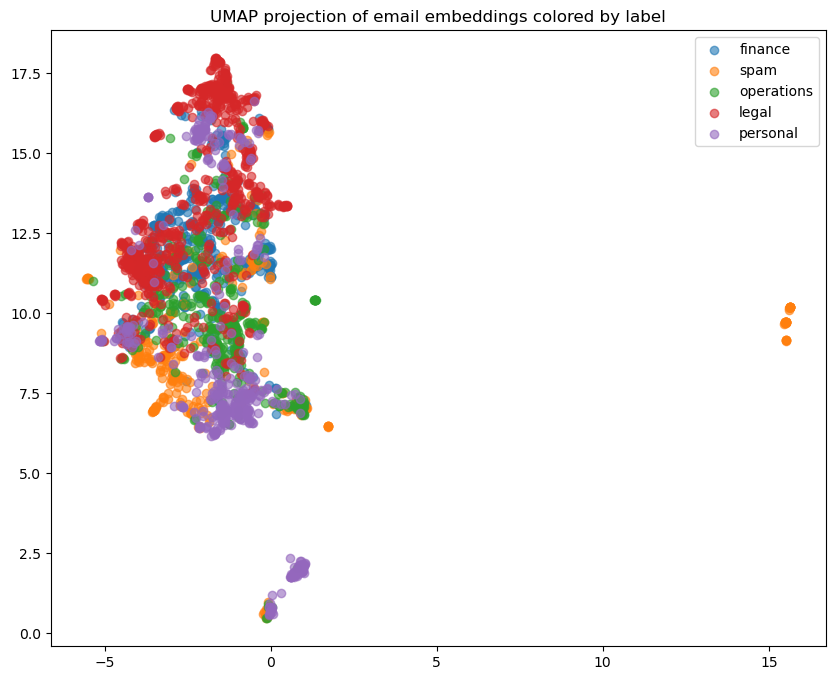

In [39]:
import umap
import matplotlib.pyplot as plt


# Assume normalised_embeddings (1000 x 384) and labels (list or array of 1000 labels)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(embeddings)  # shape (1000, 2)

# Put into a DataFrame for plotting
df_plot = pd.DataFrame({
    'x': embedding_2d[:,0],
    'y': embedding_2d[:,1],
    'label': labels.iloc[original_email_index]
})

# Plot
plt.figure(figsize=(10,8))
for lbl in df_plot['label'].unique():
    subset = df_plot[df_plot['label'] == lbl]
    plt.scatter(subset['x'], subset['y'], label=lbl, alpha=0.6)
plt.legend()
plt.title('UMAP projection of email embeddings colored by label')
plt.show()


**Plot Description:**

The UMAP plot shows that the labelled emails are not well-separated, with overlap between classifiers. 

This overlap is also why I think we see low performance. 

It could be due to inconcistency in the labelling (given the challenge I faced of staying focused labelling 1,000 emails) or not fine-tuning the embeddings. Most likely, it’s probably a mix of both.

## Summary
----

Using the 1,000 labelled emails, I evaluated the embeddings by checking how many of the k-nearest neighbors for each email shared the same label.

The average agreement was ~60%, which is moderate. This is likely due to:

    - Some overlap in email topics and content, making embeddings less separable.

    - Minor inconsistencies in manual labelling.

While not perfect, I think this score is sufficient enough for vector similarity search, since the embeddings can still capture meaningful semantic relationships. 

Based on this, I will now proceed to recreate the vector database for the full 30,000 emails. Any of the indexing methods should work, as there is not much difference between the three approaches.

## Appendix
-----

### Semantic Query Search Quick Test

In [34]:
# search_query = "fraudulent activity"
search_query = "legal issues"

In [35]:
search_query_embedding = model.encode(
    [search_query],
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [36]:
k = 5
distances, indices = IVF_index.search(search_query_embedding, k)

print("Top", k, "results for query:", search_query)
for idx in indices[0]:
    print(f"Email ID {original_email_index[idx]}: {labelled_df['email'].iloc[original_email_index[idx]]}...")

Top 5 results for query: Legal issues
Email ID 68: Caselaw Cheese and  Homepage Remove By  folks arent thinking about legal research theyre thinking about food Our answer discount subscriptions to  for  by up to 20 send you something sharp and something sweet Subscribe to TheLawnet before  and well immediately direct the farm families of the Cabot Creamery in Cabot Vermont to ship you a pint of their pure Vermont Maple Syrup and a pound of their Vintage Vermont Cheddar See see also AND  20  Just 395 save 100 on  is a custom legal browser It is very easy to use 395 covers you for  You have unlimited access to everything  at work at home and on your laptop and feelfree to hand the software off to your trusted assistant at no extra charge And did we mention theres a 30day unconditional money back guarantee  is on sale too and the prices for multiuser Workgroups look even more attractive See Of course our large competitors databases have been a work in progress for generations But times ha